# Machine Learning in Science - 2025-2026
- Teacher: Alessandro Corbetta [a.corbetta@tue.nl](mailto:a.corbetta@tue.nl)
- Co-teacher: Chiel van der Laan [c.v.d.laan@tue.nl](mailto:c.v.d.laan@tue.nl)


## [18-03-2025] - Ungraded Assignment: Predicting the hydraulic throughput of porous media

We consider the laminar flow of a viscous fluid through a porous medium, like a "sponge". The porous medium extends along the interior of a long channel (length $L$). The fluid moves under the action of a pressure drop ($\Delta P$). The system is sketched in the below, which also highlights a sample cross-section (colors representing the magnitude of the flow rate).

<center>
    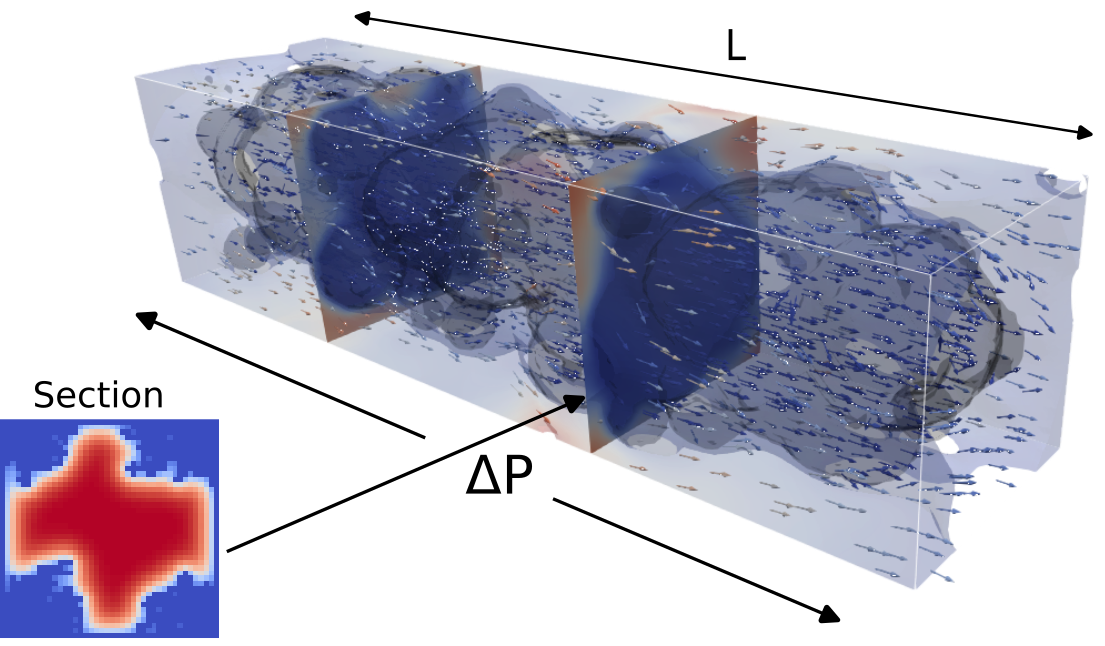
</center>

The cross-sections of the porous medium come in a wide variety of shapes. We represent cross-sections with $40\times 40$ binary images in which light pixels (pixel value = 1, or "open pixels") indicate locations through which the liquid can flow. On the other hand, dark pixels (pixel value = 0, or "closed pixels") are impermeable to flow.

Given a cross-section (i.e. a binary image), a crucial challenge in applied porous media physics is to quantify the associated laminar (non-turbulent) flow rate:


- $Q$ (in SI units measured in $m^{3}s^{-1}$).

The flow rate is determined by an interplay of the following variables (listed with SI units):

- the pressure drop $\varDelta P$ over the channel (in $Pa$),
- the length $L$ of the channel (in $m$),
- the fluid viscosity $\mu$ (in $Pa\cdot s$),
- and the area $A$ of individual pixels in the binary image (measured in $m^{2}$).

It turns out that scaling the flow rate, $Q$, by the ratio of pressure gradient $\Delta P / L$ and viscosity $\mu$, i.e. considering the **hydraulic throughput**,

$$S=\frac{\mu LQ}{\varDelta P},$$

yields a geometric parameter (measured in $m^{4}$) that is **independent on the fluid properties, the channel length, and the pressure drop**. On the contrary $S$ grows with the pixel area
(i.e. the overall area of the cross section).

**Exercise**: The goal of this exercise is to design and train a (convolutional) feedforward network that takes as input a $40\times 40$ image, and predicts the corresponding hydraulic throughput $S$. Special attention is given to hardwiring of symmetries through group averaging. 

In [1]:
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np

In [2]:
torch.manual_seed(24032025);# reproducibility, but dont use this during your gradeded assignment to get more randomness in your results

In [3]:
print(f'Is cuda available? {'Yes!' if torch.cuda.is_available() else 'No'}')
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"{device=}")

Is cuda available? Yes!
device='cuda'


### Import and inspect the data

The data is provided as four `.pt` files that each contain a single PyTorch tensor. The units of the provided data are such that the problem is **dimensionally homogeneous**.

In [4]:
class HydrolicData(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.x.size()[0]

    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [5]:
# Load and transform training data.
train_input = torch.load("./hydraulic_train_input.pt", map_location=device)
train_labels = torch.load("./hydraulic_train_labels.pt", map_location=device)
train_labels = torch.square(train_labels)

train_data = HydrolicData(train_input, train_labels)

test_input = torch.load("./hydraulic_test_input.pt", map_location=device)
test_labels = torch.load("./hydraulic_test_labels.pt", map_location=device)
test_labels = torch.square(test_labels)

In [6]:
def plot_cross_section(image, label):
    # We need to remove the batch dimension to get a 2D tensor that we can plot.
    plt.imshow(image.cpu().view(40, 40))
    plt.title(f"Hydraulic througput: {label.item():.2f}")
    plt.show()

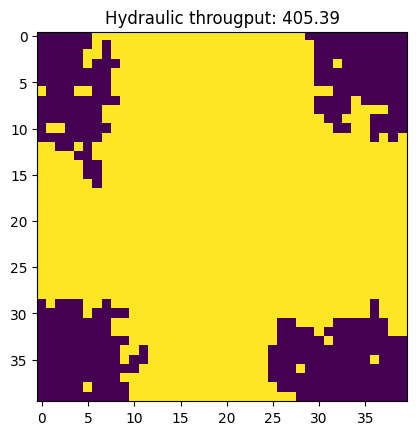

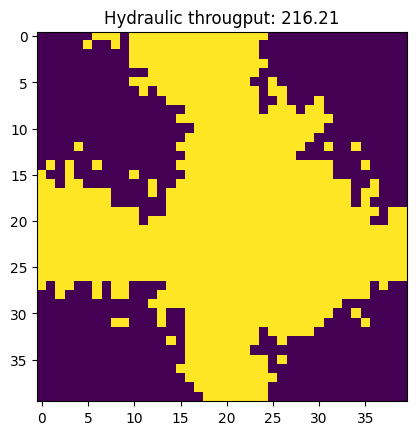

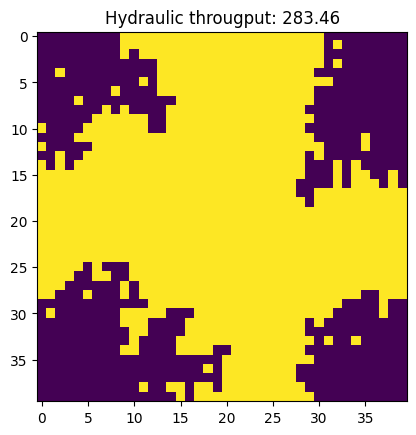

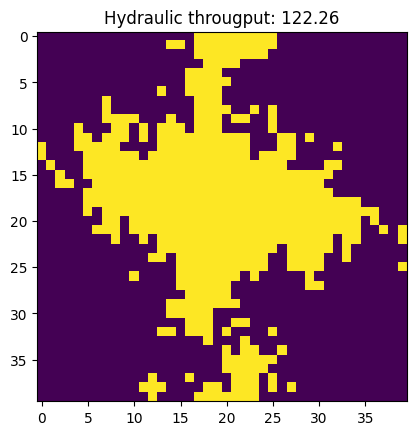

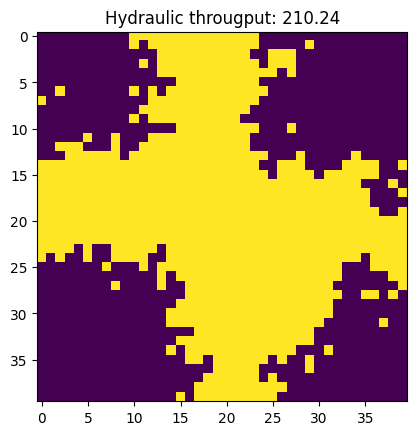

In [7]:
for i in range(5):
    plot_cross_section(train_input[i], train_labels[i])

### Training loop

The basic training loop is the same as in previous labs. It is given below for convenience.

In [8]:
def train_model(
    train_data,
    test_input,
    test_labels,
    model,
    loss_fn,
    epochs=10,
    lr=0.01,
    batch_size=1,
    print_every=1,
):
    loss_dict = {"train": [], "test": []}

    optimizer = Adam(model.parameters(), lr=lr)

    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=device))

    # Print header.
    print(f"Epoch    Train RMSRE      Test RMSRE")

    for epoch in range(epochs):
        model.train()

        epoch_loss_sum = 0

        for x_batch, y_batch in train_data_loader:
            # Reset optimizer gradients.
            optimizer.zero_grad()

            # Predict the output
            y_pred = model(x_batch)

            # Compute the loss
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        with torch.no_grad():
            model.eval()

            test_pred = model(test_input)
            test_loss = loss_fn(test_pred, test_labels)
            loss_dict["test"].append(test_loss.item())

        if (epoch + 1) % print_every == 0:
            print(
                f"{epoch+1: <7}  {loss_dict['train'][-1]: <12.6e}  {loss_dict['test'][-1]: .6e}"
            )

    return model, loss_dict

### Loss function

The loss function that we will use for this exercise is called the root-mean-square relative error (RMSRE),

$$ \text{RMSRE}={\textstyle \sqrt{ {\displaystyle  \frac{1}{N}\sum_{i=1}^{N}}\left(\frac{S^{(i)}-T^{(i)}}{T^{(i)}}\right)^{2}}}, $$

where $S^{(i)}$ is the prediction for sample $i$, and $T^{(i)}$ is the corresponding label. This loss function is not part of the default options provided by PyTorch, therefore the implementation is given below.

In [9]:
def rmsre(pred, truth):
    return ((pred - truth) / truth).square().mean().sqrt()

### Naive 2D convolutional model

Your first task is to implement a naive 2D convolutional model, i.e. a model that does not respect (all) the symmetries of the problem.

- Implement a 1D convolutional model to tackle this challenge (the layers of interest are `Conv2D`, `MaxPool2D`, and `Flatten`).
- Use the model we implemented in the last lab as inspiration for your model architecture. Remember that we are currently dealing with a regression problem instead of a classification problem. You can also decrease the number of filters (channels) in the `Conv2D` layers.
- Dropout layers can be omitted for this problem.

In [10]:
def create_model(num_channels=8, bias=False):
    return nn.Sequential(
        nn.Conv2d(1,num_channels,kernel_size=3,stride=1, padding=1, bias=bias),
        nn.ReLU(),
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1,bias=bias),
        nn.ReLU(),
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1,bias=bias),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1, bias=bias),
        nn.ReLU(),
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1,bias=bias),
        nn.ReLU(),
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1,bias=bias),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1, bias=bias),
        nn.ReLU(),
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1,bias=bias),
        nn.ReLU(),
        nn.Conv2d(num_channels,num_channels,kernel_size=3,stride=1, padding=1,bias=bias),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        
        nn.Flatten(),
        # Adjust the input features to match your final feature map size
        nn.Linear(40*40//(2+2)**3 *num_channels, 32, bias=bias),
        nn.ReLU(),
        nn.Linear(32, 16, bias=bias),
        nn.ReLU(),
        nn.Linear(16, 1, bias=bias),
        
    )

### Train your naive model

Take note of the following:
 - Use the RMSRE loss as your loss function.
 - Plot the resulting train and test loss curves. Is your model under/overfitting?
 - Training your model is computationally expensive, using a GPU for training is advised (you can use Google colab to get access to a free GPU)!

In [11]:
model, loss_dict = train_model(
    train_data,
    test_input,
    test_labels,
    create_model().to(device),
    rmsre,
    1000,
    1e-4,
    32,
    50,
)

Epoch    Train RMSRE      Test RMSRE
50       8.706162e-02   1.125909e-01
100      5.898442e-02   7.946850e-02
150      4.091539e-02   6.765868e-02
200      2.761332e-02   5.848297e-02
250      2.237594e-02   5.750083e-02
300      2.006181e-02   5.091070e-02
350      1.782128e-02   4.584622e-02
400      1.636372e-02   5.051460e-02
450      1.578168e-02   5.247650e-02
500      1.528906e-02   4.680608e-02
550      1.336602e-02   4.518856e-02
600      1.290130e-02   4.884790e-02
650      1.272410e-02   4.619801e-02
700      1.161981e-02   4.854596e-02
750      1.205016e-02   4.592304e-02
800      1.095213e-02   4.849217e-02
850      1.086178e-02   4.738002e-02
900      1.075011e-02   4.498526e-02
950      1.015228e-02   4.248504e-02
1000     1.128900e-02   4.365636e-02


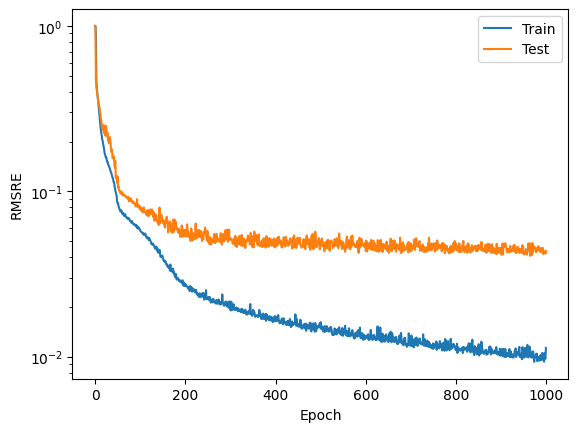

In [12]:
plt.plot(loss_dict["train"], label="Train")
plt.plot(loss_dict["test"], label="Test")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("RMSRE")

plt.legend()
plt.show()

### Show that your naive model does not respect the symmetries of the problem

You can verify that your model does not respect these symmetries by applying the following procedure:

1. Do a prediction on the identity ($Y_{identity}$).
2. Apply a symmetry transformation to the sample (e.g. reflection along the an axis)
3. Compute the prediction of your model for the transformed sample($Y_{reflection}$).
4. Compare the two predictions. $|Y_{identity} - Y_{reflection}|$

If $|Y_{identity} - Y_{reflection}| \neq 0$ your model does not respect the symmetry transformation that you applied. 

If you want you can repeat this procedure for all symmetry transformations of interest.

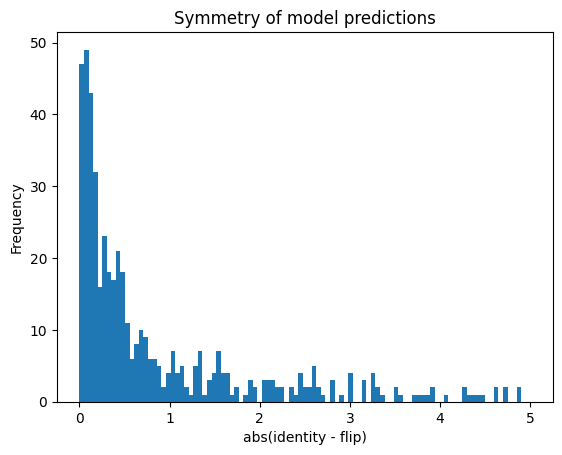

In [22]:
def flip(x):
    return torch.flip(x,[-1])

with torch.no_grad():
    normal_output = model(test_input) 
    flip_output = model(flip(test_input))
    simple_sym_diff = torch.abs(normal_output - flip_output)
    bins= torch.linspace(0,5,100)
    plt.hist(simple_sym_diff.detach().cpu(),bins.detach().cpu())
    plt.xlabel("abs(identity - flip)")
    plt.ylabel("Frequency")
    plt.title("Symmetry of model predictions")
    plt.show()

### Incorporating symmetries by group-averaging

**Identifying the symmetry group**: Before we can incorporate any symmetries, you need to identify the symmetry group whose operations respect the in/equivariance of the problem. We will call this symmetry group $\mathcal{G}$.

**Implementation**: The next challenge is to hardwire the problem symmetries in the model. The technique that you will be using is called group-averaging. Group-averaging essentially comprises two steps.

1. Before an input is fed to the model, each symmetry operation is applied once to the input. The resulting $|\mathcal{G}|$ symmetrically equivalent inputs are then pushed through the **same** model.
2. The $|\mathcal{G}|$ outputs are then averaged. The resulting average is the final prediction of the model.

You will implement group-averaging by writing a wrapper module `GroupAvgModel` that takes any base model as its argument and makes it a group averaged model. You can implement a custom module by extending `torch.nn.Module` and overriding the `forward` method.

In the `forward` method of `GroupAvgModel`, you should:

1. Apply all $|\mathcal{G}|$ symmetry operations to the input `x` to obtain a list of symmetrically equivalent inputs. You can for example store them in a list.
2. Pass each transformed input through `self.model` and accumulate the outputs.
3. Return the mean of the $|\mathcal{G}|$ outputs.

In [14]:
def flip(x):
    return torch.flip(x,[-1])

def rot(x):
    return torch.rot90(x,k=1,dims=(-2,-1))

class GroupAvgModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        identity = x
        sym1 = flip(x)
        sym2 = rot(x)
        sym3 = rot(sym2)
        sym4 = rot(sym3)
        sym5 = rot(sym1)
        sym6 = rot(sym5)
        sym7 = rot(sym6)
        
        list_to_group_avg = [identity,sym1, sym2,sym3,sym4,sym5,sym6,sym7]
        
        # Create a tensor to store the accumulated output of the model for each symmetry transformed input
        output_total = torch.zeros((len(x),1))
        for group_i in list_to_group_avg:
            output_i = self.model(group_i)
            output_total += output_i
            
        # take the mean of the accumulated output
        return output_total / len(list_to_group_avg)

Use the new `GroupAvgModel` wrapper to make your naive model a group-averaged model. You can for example implement a new function `create_model_ga` that creates a group-averaged version of the naive model created by `create_model`.

In [15]:
def create_model_ga(num_channels=8, bias=False):
    main_model = create_model(num_channels,bias)
    return nn.Sequential(
        GroupAvgModel(main_model)
    )

### Train your group-averaging model

Take note of the following:
 - Use the RMSRE loss as your loss function.
 - Plot the resulting train and test loss curves. Is your model under/overfitting?
 - Training your model is computationally expensive, using a GPU for training is advised (you can use Google colab to get access to a free GPU)!

In [16]:
model_ga, loss_dict_ga = train_model(
    train_data,
    test_input,
    test_labels,
    create_model_ga().to(device),
    rmsre,
    1000,
    1e-4,
    32,
    50,
)

Epoch    Train RMSRE      Test RMSRE
50       8.858048e-02   8.470912e-02
100      3.663394e-02   4.122401e-02
150      2.506842e-02   2.815088e-02
200      2.082719e-02   2.208573e-02
250      1.655939e-02   1.797050e-02
300      1.536527e-02   1.581241e-02
350      1.309012e-02   1.385352e-02
400      1.291644e-02   1.219373e-02
450      1.124116e-02   1.222135e-02
500      1.100022e-02   1.204408e-02
550      1.090919e-02   1.251073e-02
600      1.078534e-02   1.105233e-02
650      9.627355e-03   1.159073e-02
700      9.835904e-03   9.982593e-03
750      9.253251e-03   9.842296e-03
800      8.593528e-03   9.292781e-03
850      8.885719e-03   1.006505e-02
900      8.135370e-03   9.466340e-03
950      7.846495e-03   9.196844e-03
1000     7.537981e-03   9.728181e-03


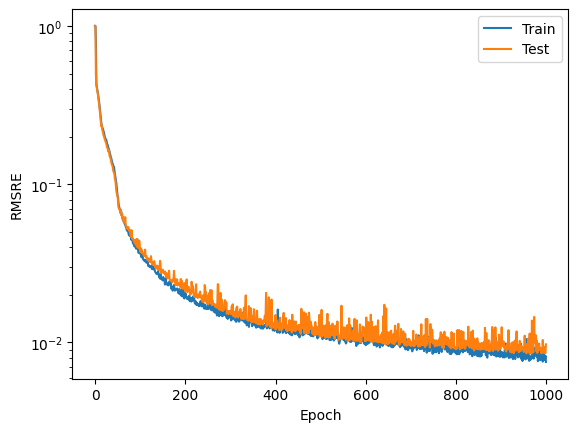

In [17]:
plt.plot(loss_dict_ga["train"], label="Train")
plt.plot(loss_dict_ga["test"], label="Test")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("RMSRE")

plt.legend()
plt.show()

### Show that this model does not respect the symmetries of the problem
Use the same procedure as before to verify that your group-averaging model respects the symmetries of the problem. You should find that $|Y_{identity} - Y_{reflection}| < 1 \cdot 10^{-4} \approx 0$ for all symmetry transformations that you apply.

Note that due to numerical precision issues, the predictions of the model on symmetrically equivalent configurations might not be exactly equal. 

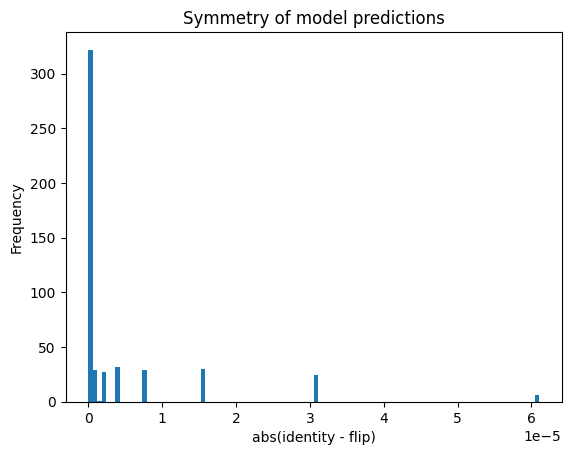

In [18]:
with torch.no_grad():
    normal_output = model_ga(test_input) 
    flip_output = model_ga(flip(test_input))
    simple_sym_diff = torch.abs(normal_output - flip_output)
    plt.hist(simple_sym_diff.detach().cpu(),100)
    plt.xlabel("abs(identity - flip)")
    plt.ylabel("Frequency")
    plt.title("Symmetry of model predictions")
    plt.show()

### Model comparison

Plot and compare the test performance of the naive and group-averaging models. Use similar configurations for both models (same number of layers, same channel sizes, etc.).

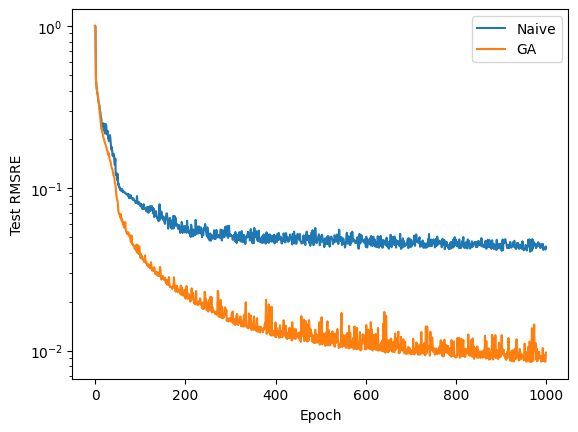

In [19]:
plt.plot(loss_dict["test"], label="Naive")
plt.plot(loss_dict_ga["test"], label="GA")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Test RMSRE")

plt.legend()
plt.show()

Compare the number of parameters, what do you expect?

In [20]:
def num_params(model):
    return sum((param.numel() for param in model.parameters()))

In [21]:
print(num_params(model))
print(num_params(model_ga))

11608
11608
